<a href="https://colab.research.google.com/github/eoinjphillips-beep/ELE2038-control-coursework--40438350-/blob/main/crane_control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 9.5 MB/s eta 0:00:00


a3 = 206600000.00
a2 = 168284735.00
a1 = 152679200.00
a0 = 80442000.00


/usr/local/lib/python3.12/dist-packages/control/freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


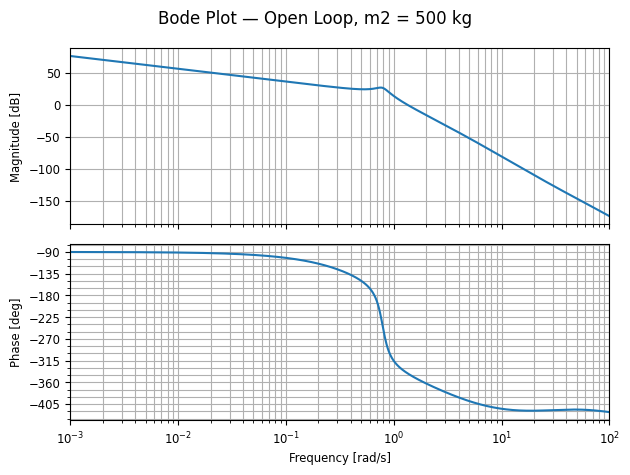

Gain margin:  -25.19 dB at 0.6613 rad/s
Phase margin: -160.99 deg at 1.3334 rad/s


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import control

m1 = 1033
m2 = 500
mtot = m1 + m2
L = 20
bx = 820
btheta = 2795
g = 9.81
Ka = 5200
tau1 = 0.270
tau2 = 0.010

a3 = m1 * m2 * L**2
a2 = bx * m2 * L**2 + btheta * mtot
a1 = m2 * g * L * mtot + bx * btheta
a0 = m2 * bx * g * L

print(f"a3 = {a3:.2f}")
print(f"a2 = {a2:.2f}")
print(f"a1 = {a1:.2f}")
print(f"a0 = {a0:.2f}")

plant_num = [btheta, m2 * g * L]
plant_den = [a3, a2, a1, a0, 0]
Gp = control.tf(plant_num, plant_den)

act_den = np.polymul([tau1, 1], [tau2, 1])
Ga = control.tf([Ka], act_den)

tau_s = 0.05
Gs = control.tf([1], [tau_s, 1])

G = Ga * Gp

mag, phase, omega = control.bode(G,
                                  omega_limits=[1e-3, 1e2],
                                  dB=True,
                                  deg=True,
                                  plot=True)
plt.suptitle("Bode Plot — Open Loop, m2 = 500 kg")
plt.tight_layout()
plt.savefig("bode_openloop.png", dpi=150, bbox_inches='tight')
plt.show()

gm, pm, wg, wp = control.margin(G)
print(f"Gain margin:  {20*np.log10(gm):.2f} dB at {wg:.4f} rad/s")
print(f"Phase margin: {pm:.2f} deg at {wp:.4f} rad/s")

Gain margin:  9.73 dB at 0.7998 rad/s
Phase margin: 61.94 deg at 0.0346 rad/s


/usr/local/lib/python3.12/dist-packages/control/freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


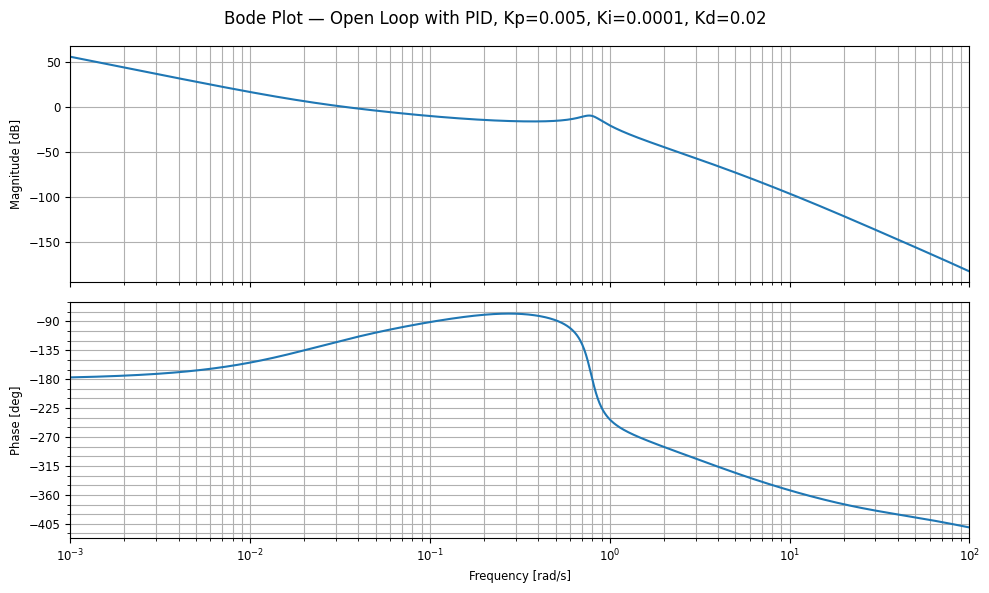

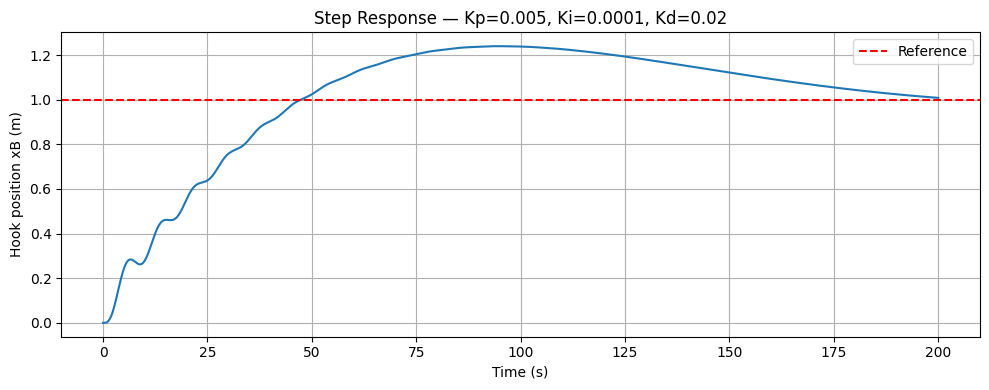


Settling time:  283.74 s
Overshoot:      23.98 %
Rise time:      36.78 s


In [4]:
Kp = 0.005
Ki = 0.0001
Kd = 0.02

pid_num = [Kd, Kp, Ki]
pid_den = [1, 0]
C = control.tf(pid_num, pid_den)

L_open = C * G * Gs

gm, pm, wg, wp = control.margin(L_open)
print(f"Gain margin:  {20*np.log10(gm):.2f} dB at {wg:.4f} rad/s")
print(f"Phase margin: {pm:.2f} deg at {wp:.4f} rad/s")

plt.figure(figsize=(10,6))
control.bode(L_open,
             omega_limits=[1e-3, 1e2],
             dB=True,
             deg=True,
             plot=True)
plt.suptitle(f"Bode Plot — Open Loop with PID, Kp={Kp}, Ki={Ki}, Kd={Kd}")
plt.tight_layout()
plt.savefig("bode_pid.png", dpi=150, bbox_inches='tight')
plt.show()

T = control.feedback(C * G, Gs)
t, y = control.step_response(T, T=np.linspace(0, 200, 5000))

plt.figure(figsize=(10,4))
plt.plot(t, y)
plt.axhline(1.0, color='r', linestyle='--', label='Reference')
plt.xlabel("Time (s)")
plt.ylabel("Hook position xB (m)")
plt.title(f"Step Response — Kp={Kp}, Ki={Ki}, Kd={Kd}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("step_response.png", dpi=150, bbox_inches='tight')
plt.show()

info = control.step_info(T)
print(f"\nSettling time:  {info['SettlingTime']:.2f} s")
print(f"Overshoot:      {info['Overshoot']:.2f} %")
print(f"Rise time:      {info['RiseTime']:.2f} s")

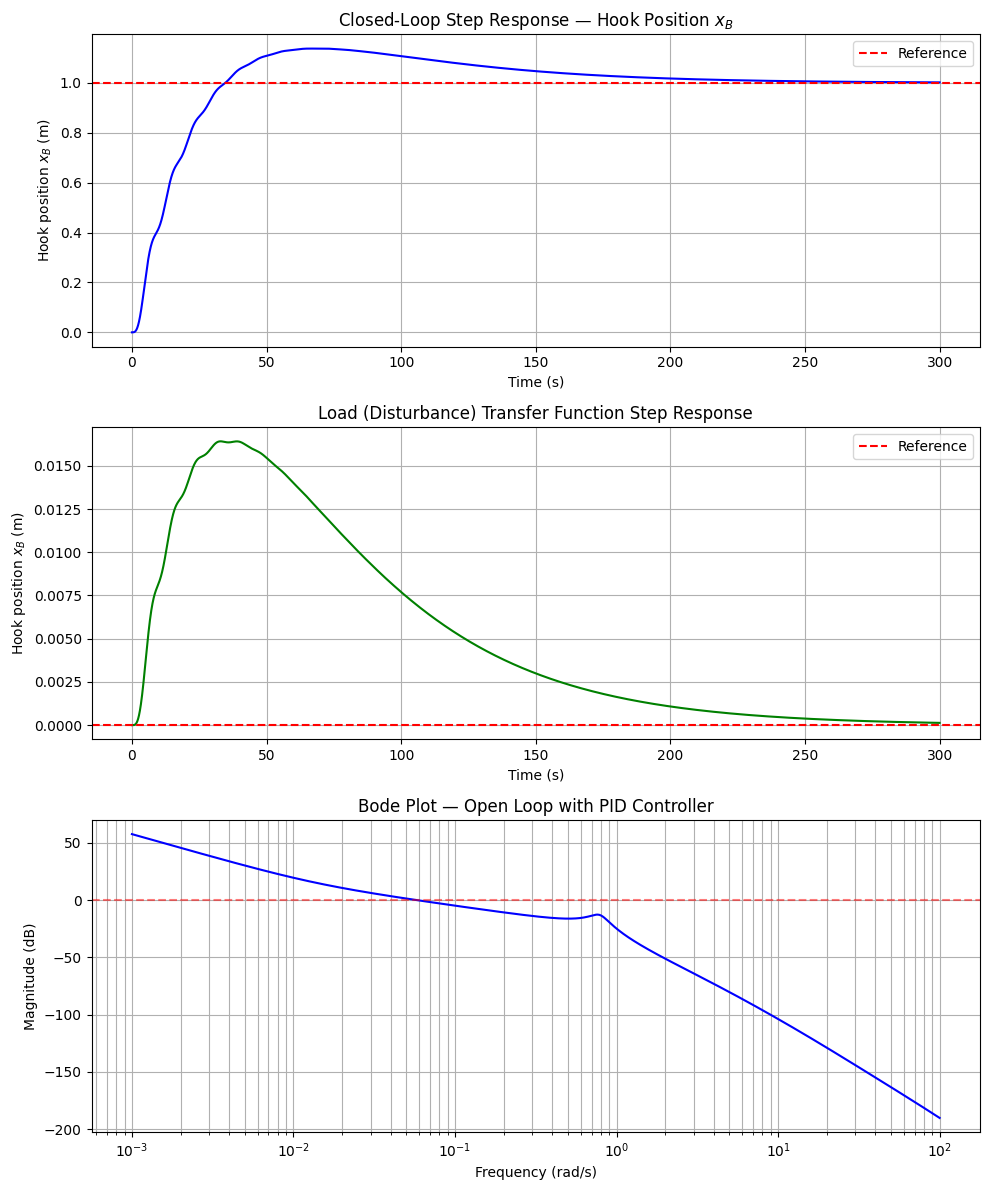

Final Controller: Kp=0.009, Ki=0.00012, Kd=0.008
Gain margin:      12.85 dB at 0.7365 rad/s
Phase margin:     72.59 deg at 0.0580 rad/s
Settling time:    194.00 s
Overshoot:        13.79 %
Rise time:        24.05 s

Closed-loop poles:
  -100.000000+0.000000j
  -20.000006+0.000000j
  -3.702317+0.000000j
  -0.604054+0.000000j
  -0.076033+0.769053j
  -0.076033-0.769053j
  -0.038418+0.000000j
  -0.021386+0.000000j


In [5]:
Kp = 0.009
Ki = 0.00012
Kd = 0.008

C_final = control.tf([Kd, Kp, Ki], [1, 0])
T_final = control.feedback(C_final * G, Gs)
L_final = C_final * G * Gs

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

t, y = control.step_response(T_final, T=np.linspace(0, 300, 8000))
axes[0].plot(t, y, 'b', linewidth=1.5)
axes[0].axhline(1.0, color='r', linestyle='--', label='Reference')
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Hook position $x_B$ (m)")
axes[0].set_title("Closed-Loop Step Response — Hook Position $x_B$")
axes[0].legend()
axes[0].grid(True)

Td = control.tf([1, 0], [1]) * control.tf(
    [btheta, m2*g*L], [a3, a2, a1, a0, 0])
Td_cl = control.feedback(Gp, C_final * Ga * Gs)
t2, y2 = control.step_response(Td_cl, T=np.linspace(0, 300, 8000))
axes[1].plot(t2, y2, 'g', linewidth=1.5)
axes[1].axhline(0.0, color='r', linestyle='--', label='Reference')
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Hook position $x_B$ (m)")
axes[1].set_title("Load (Disturbance) Transfer Function Step Response")
axes[1].legend()
axes[1].grid(True)

mag, phase, omega = control.frequency_response(L_final,
                                                omega_limits=[1e-3, 1e2])
mag_db = 20 * np.log10(np.abs(mag))
phase_deg = np.angle(mag, deg=True) % -360 + 360
phase_deg = np.angle(mag, deg=True)

axes[2].semilogx(omega, mag_db, 'b', linewidth=1.5)
axes[2].axhline(0, color='r', linestyle='--', alpha=0.5)
axes[2].set_xlabel("Frequency (rad/s)")
axes[2].set_ylabel("Magnitude (dB)")
axes[2].set_title("Bode Plot — Open Loop with PID Controller")
axes[2].grid(True, which='both')

plt.tight_layout()
plt.savefig("report_plots.png", dpi=150, bbox_inches='tight')
plt.show()

gm, pm, wg, wp = control.margin(L_final)
print(f"Final Controller: Kp={Kp}, Ki={Ki}, Kd={Kd}")
print(f"Gain margin:      {20*np.log10(gm):.2f} dB at {wg:.4f} rad/s")
print(f"Phase margin:     {pm:.2f} deg at {wp:.4f} rad/s")

info = control.step_info(T_final)
print(f"Settling time:    {info['SettlingTime']:.2f} s")
print(f"Overshoot:        {info['Overshoot']:.2f} %")
print(f"Rise time:        {info['RiseTime']:.2f} s")

poles = control.poles(T_final)
print(f"\nClosed-loop poles:")
for p in sorted(poles, key=lambda x: x.real):
    print(f"  {p:.6f}")

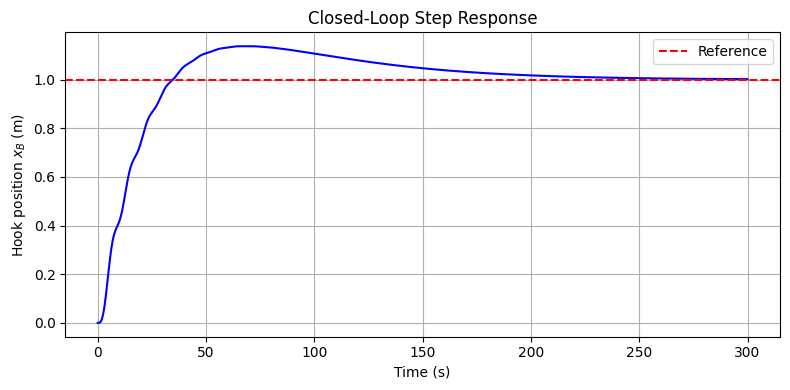

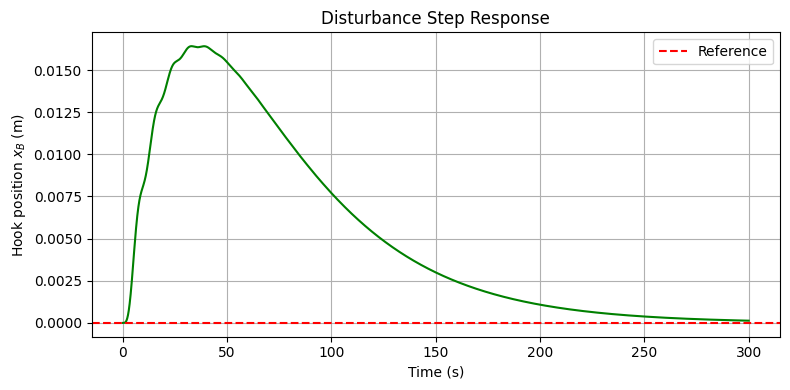

/usr/local/lib/python3.12/dist-packages/control/freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


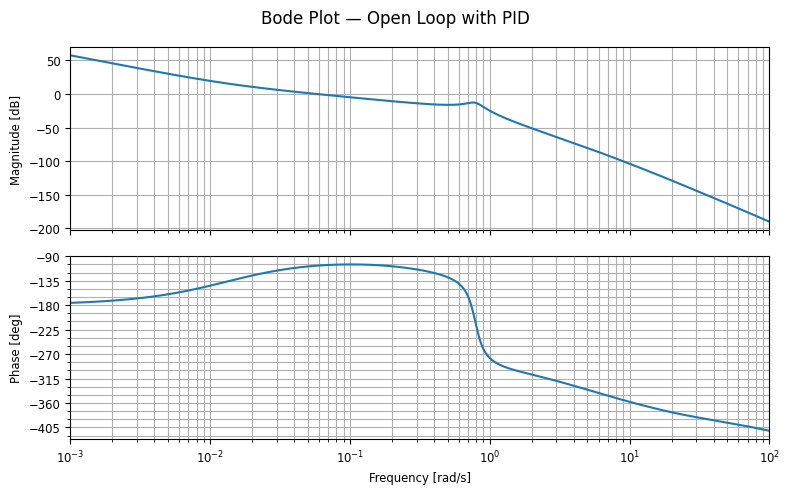

All plots saved.


In [6]:
Kp = 0.009
Ki = 0.00012
Kd = 0.008

C_final = control.tf([Kd, Kp, Ki], [1, 0])
T_final = control.feedback(C_final * G, Gs)
L_final = C_final * G * Gs

t, y = control.step_response(T_final, T=np.linspace(0, 300, 8000))
plt.figure(figsize=(8, 4))
plt.plot(t, y, 'b', linewidth=1.5)
plt.axhline(1.0, color='r', linestyle='--', label='Reference')
plt.xlabel("Time (s)")
plt.ylabel("Hook position $x_B$ (m)")
plt.title("Closed-Loop Step Response")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("step_response_final.png", dpi=150, bbox_inches='tight')
plt.show()

Td_cl = control.feedback(Gp, C_final * Ga * Gs)
t2, y2 = control.step_response(Td_cl, T=np.linspace(0, 300, 8000))
plt.figure(figsize=(8, 4))
plt.plot(t2, y2, 'g', linewidth=1.5)
plt.axhline(0.0, color='r', linestyle='--', label='Reference')
plt.xlabel("Time (s)")
plt.ylabel("Hook position $x_B$ (m)")
plt.title("Disturbance Step Response")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("disturbance_response.png", dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 5))
control.bode(L_final,
             omega_limits=[1e-3, 1e2],
             dB=True,
             deg=True,
             plot=True)
plt.suptitle("Bode Plot — Open Loop with PID")
plt.tight_layout()
plt.savefig("bode_with_pid.png", dpi=150, bbox_inches='tight')
plt.show()

print("All plots saved.")

In [7]:
import numpy as np
from numpy.polynomial import polynomial as P

Kp = 0.009
Ki = 0.00012
Kd = 0.008

cl_poles = control.poles(T_final)
print("Closed-loop poles (checking stability):")
print(f"{'Pole':<35} {'Real part':<15} {'Stable?'}")
print("-" * 60)
for p in sorted(cl_poles, key=lambda x: x.real):
    stable = "YES" if p.real < 0 else "NO"
    print(f"  {str(p):<35} {p.real:<15.6f} {stable}")

all_stable = all(p.real < 0 for p in cl_poles)
print(f"\nAll poles in left half plane: {all_stable}")
print(f"Conclusion: Closed-loop system is {'STABLE' if all_stable else 'UNSTABLE'}")

print(f"\nFinal Value Theorem — steady-state error check:")
print(f"Open loop has 2 integrators (plant + PID integral term)")
print(f"=> Zero steady-state error for step input guaranteed")

Closed-loop poles (checking stability):
Pole                                Real part       Stable?
------------------------------------------------------------
  (-100.0000000350085+0j)             -100.000000     YES
  (-20.00000592639482+0j)             -20.000006      YES
  (-3.702316954190207+0j)             -3.702317       YES
  (-0.6040537361586444+0j)            -0.604054       YES
  (-0.07603310286136304+0.76905331991642j) -0.076033       YES
  (-0.07603310286136304-0.76905331991642j) -0.076033       YES
  (-0.038418346540798926+0j)          -0.038418       YES
  (-0.021386231537005498+0j)          -0.021386       YES

All poles in left half plane: True
Conclusion: Closed-loop system is STABLE

Final Value Theorem — steady-state error check:
Open loop has 2 integrators (plant + PID integral term)
=> Zero steady-state error for step input guaranteed


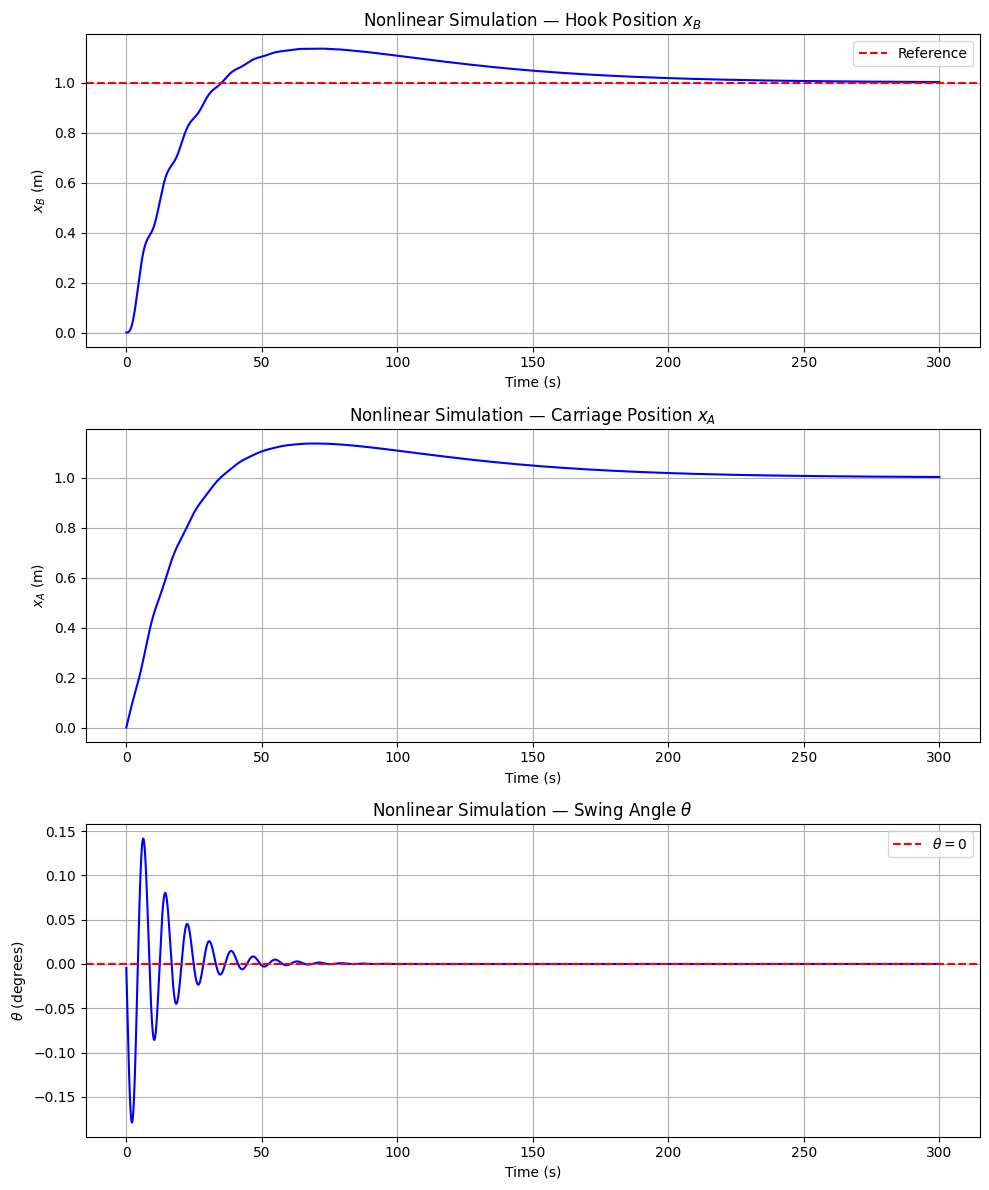

Max swing angle: 0.1790 degrees
Final xB: 1.0022 m
Final xA: 1.0022 m
Final theta: -0.0000 degrees


In [8]:
from scipy.integrate import solve_ivp

Kp = 0.009
Ki = 0.00012
Kd = 0.008

x_ref = 1.0
t_span = (0, 300)
t_eval = np.linspace(0, 300, 8000)

def actuator_ode(t, x_act, v_input):
    F = x_act[1]
    dF = (Ka * v_input - (tau1 + tau2) * x_act[1] - x_act[0]) / (tau1 * tau2)
    dx1 = x_act[1]
    dx2 = dF
    return [dx1, dx2]

def crane_nonlinear(t, state, params):
    xA, xA_dot, theta, theta_dot, integral_e, prev_e, F = state
    m1, m2, L, bx, btheta, g, Ka, tau1, tau2 = params
    mtot = m1 + m2

    xB = xA + L * np.sin(theta)
    e = x_ref - xB

    de = (e - prev_e) / 1e-6 if t == 0 else 0

    v = Kp * e + Ki * integral_e + Kd * (e - prev_e) / 0.0375
    v = np.clip(v, -1.0, 1.0)

    F_new = Ka * v

    M = np.array([
        [mtot, m2 * L * np.cos(theta)],
        [m2 * L * np.cos(theta), m2 * L**2]
    ])

    rhs = np.array([
        F_new - bx * xA_dot - m2 * L * (-theta_dot**2 * np.sin(theta)),
        -btheta * theta_dot - m2 * g * L * np.sin(theta)
    ])

    accel = np.linalg.solve(M, rhs)
    xA_ddot = accel[0]
    theta_ddot = accel[1]

    d_integral = e
    d_prev_e = e

    return [xA_dot, xA_ddot, theta_dot, theta_ddot,
            d_integral, d_prev_e, F_new - F]

params = (m1, m2, L, bx, btheta, g, Ka, tau1, tau2)
state0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

integral_e = 0.0
prev_e = 0.0
dt = t_eval[1] - t_eval[0]

xA_hist = []
xB_hist = []
theta_hist = []
F_hist = []
t_hist = []

xA = 0.0
xA_dot = 0.0
theta = 0.0
theta_dot = 0.0
F = 0.0

for i, t in enumerate(t_eval[:-1]):
    xB = xA + L * np.sin(theta)
    e = x_ref - xB

    v = Kp * e + Ki * integral_e + Kd * (e - prev_e) / dt
    v = np.clip(v, -1.0, 1.0)
    F = Ka * v

    mtot = m1 + m2
    M = np.array([
        [mtot, m2 * L * np.cos(theta)],
        [m2 * L * np.cos(theta), m2 * L**2]
    ])
    rhs = np.array([
        F - bx * xA_dot + m2 * L * theta_dot**2 * np.sin(theta),
        -btheta * theta_dot - m2 * g * L * np.sin(theta)
    ])
    accel = np.linalg.solve(M, rhs)
    xA_ddot = accel[0]
    theta_ddot = accel[1]

    xA_dot += xA_ddot * dt
    xA += xA_dot * dt
    theta_dot += theta_ddot * dt
    theta += theta_dot * dt

    integral_e += e * dt
    prev_e = e

    xA_hist.append(xA)
    xB_hist.append(xB)
    theta_hist.append(np.degrees(theta))
    F_hist.append(F)
    t_hist.append(t)

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

axes[0].plot(t_hist, xB_hist, 'b', linewidth=1.5)
axes[0].axhline(x_ref, color='r', linestyle='--', label='Reference')
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("$x_B$ (m)")
axes[0].set_title("Nonlinear Simulation — Hook Position $x_B$")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t_hist, xA_hist, 'b', linewidth=1.5)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("$x_A$ (m)")
axes[1].set_title("Nonlinear Simulation — Carriage Position $x_A$")
axes[1].grid(True)

axes[2].plot(t_hist, theta_hist, 'b', linewidth=1.5)
axes[2].axhline(0, color='r', linestyle='--', label='$\\theta = 0$')
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("$\\theta$ (degrees)")
axes[2].set_title("Nonlinear Simulation — Swing Angle $\\theta$")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig("nonlinear_simulation.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Max swing angle: {max(abs(np.array(theta_hist))):.4f} degrees")
print(f"Final xB: {xB_hist[-1]:.4f} m")
print(f"Final xA: {xA_hist[-1]:.4f} m")
print(f"Final theta: {theta_hist[-1]:.4f} degrees")

m2 = 100 kg:
  Gain margin:   7.01 dB
  Phase margin:  74.23 deg
  Settling time: 195.36 s
  Overshoot:     14.35 %

m2 = 500 kg:
  Gain margin:   12.85 dB
  Phase margin:  72.59 deg
  Settling time: 194.00 s
  Overshoot:     13.79 %

m2 = 1000 kg:
  Gain margin:   19.02 dB
  Phase margin:  70.56 deg
  Settling time: 192.80 s
  Overshoot:     14.21 %

Parameter misestimation — max tolerable error:
Parameter    Factor   GM (dB)      PM (deg)     Stable
-------------------------------------------------------
bx           0.50     11.50        64.21        True
bx           0.75     12.35        71.64        True
bx           1.25     13.20        71.50        True
bx           1.50     13.46        69.72        True
bx           2.00     13.87        65.72        True
btheta       0.50     12.50        72.59        True
btheta       0.75     12.68        72.59        True
btheta       1.25     13.03        72.59        True
btheta       1.50     13.19        72.59        True
btheta     

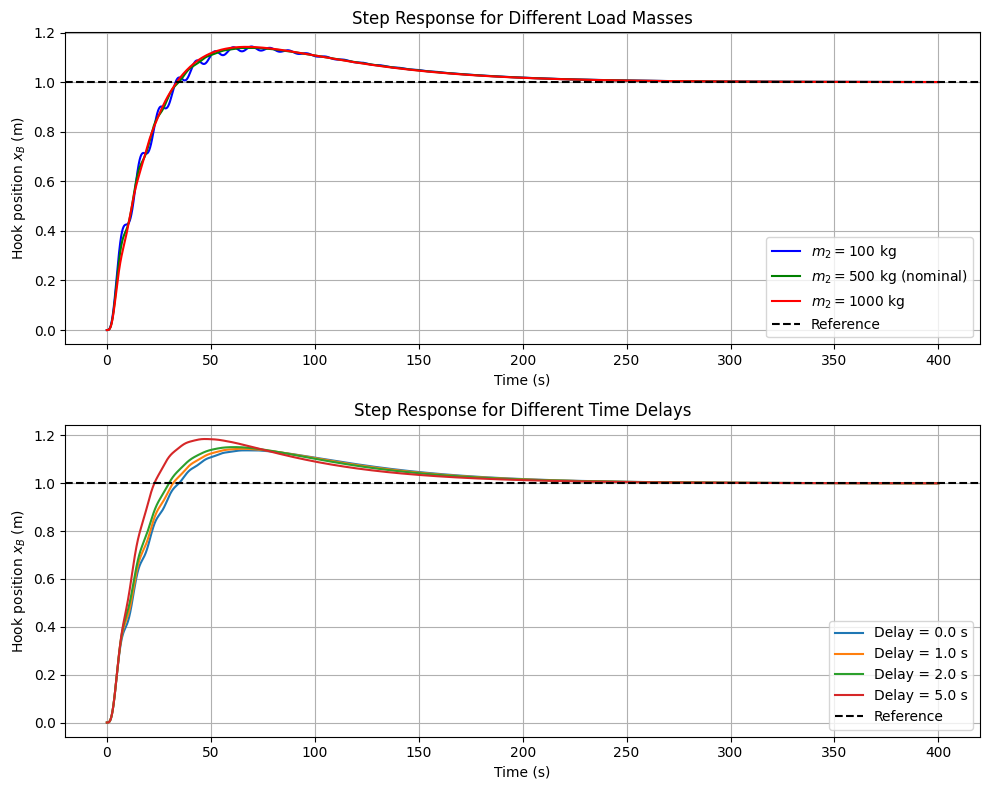

In [9]:
Kp = 0.009
Ki = 0.00012
Kd = 0.008
C_final = control.tf([Kd, Kp, Ki], [1, 0])

m2_values = [100, 500, 1000]
colours = ['blue', 'green', 'red']
labels = ['$m_2 = 100$ kg', '$m_2 = 500$ kg (nominal)', '$m_2 = 1000$ kg']

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

for m2_test, col, lab in zip(m2_values, colours, labels):
    mtot_test = m1 + m2_test
    a3_t = m1 * m2_test * L**2
    a2_t = bx * m2_test * L**2 + btheta * mtot_test
    a1_t = m2_test * g * L * mtot_test + bx * btheta
    a0_t = m2_test * bx * g * L

    Gp_t = control.tf([btheta, m2_test * g * L],
                       [a3_t, a2_t, a1_t, a0_t, 0])
    act_den_t = np.polymul([tau1, 1], [tau2, 1])
    Ga_t = control.tf([Ka], act_den_t)
    G_t = Ga_t * Gp_t
    T_t = control.feedback(C_final * G_t, Gs)

    try:
        t, y = control.step_response(T_t, T=np.linspace(0, 400, 8000))
        info = control.step_info(T_t)
        gm, pm, wg, wp = control.margin(C_final * G_t * Gs)
        print(f"m2 = {m2_test} kg:")
        print(f"  Gain margin:   {20*np.log10(gm):.2f} dB")
        print(f"  Phase margin:  {pm:.2f} deg")
        print(f"  Settling time: {info['SettlingTime']:.2f} s")
        print(f"  Overshoot:     {info['Overshoot']:.2f} %")
        print()
        axes[0].plot(t, y, color=col, linewidth=1.5, label=lab)
    except:
        print(f"m2 = {m2_test} kg: failed")

axes[0].axhline(1.0, color='k', linestyle='--', label='Reference')
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Hook position $x_B$ (m)")
axes[0].set_title("Step Response for Different Load Masses")
axes[0].legend()
axes[0].grid(True)

params_to_test = {
    'bx': (bx, 'b_x'),
    'btheta': (btheta, 'b_\\theta'),
    'Ka': (Ka, 'K_a'),
    'L': (L, 'L'),
    'tau1': (tau1, '\\tau_1'),
    'tau2': (tau2, '\\tau_2')
}

print("Parameter misestimation — max tolerable error:")
results = []
for param_name, (nominal, latex_name) in params_to_test.items():
    for factor in [0.5, 0.75, 1.25, 1.5, 2.0]:
        try:
            bx_t = bx if param_name != 'bx' else nominal * factor
            btheta_t = btheta if param_name != 'btheta' else nominal * factor
            Ka_t = Ka if param_name != 'Ka' else nominal * factor
            L_t = L if param_name != 'L' else nominal * factor
            tau1_t = tau1 if param_name != 'tau1' else nominal * factor
            tau2_t = tau2 if param_name != 'tau2' else nominal * factor

            mtot_t = m1 + m2
            a3_t = m1 * m2 * L_t**2
            a2_t = bx_t * m2 * L_t**2 + btheta_t * mtot_t
            a1_t = m2 * g * L_t * mtot_t + bx_t * btheta_t
            a0_t = m2 * bx_t * g * L_t

            Gp_t = control.tf([btheta_t, m2 * g * L_t],
                               [a3_t, a2_t, a1_t, a0_t, 0])
            Ga_t = control.tf([Ka_t],
                               np.polymul([tau1_t, 1], [tau2_t, 1]))
            G_t = Ga_t * Gp_t
            L_ol = C_final * G_t * Gs
            gm, pm, wg, wp = control.margin(L_ol)
            gm_db = 20 * np.log10(abs(gm))
            stable = gm_db > 0 and pm > 0
            results.append((param_name, latex_name, factor, gm_db, pm, stable))
        except:
            pass

print(f"{'Parameter':<12} {'Factor':<8} {'GM (dB)':<12} {'PM (deg)':<12} {'Stable'}")
print("-" * 55)
for r in results:
    print(f"{r[0]:<12} {r[2]:<8.2f} {r[3]:<12.2f} {r[4]:<12.2f} {r[5]}")

delays = np.linspace(0, 5, 100)
max_stable_delay = 0
for delay in delays:
    try:
        Gs_delay = control.tf(*control.pade(delay, 2)) * Gs
        L_ol = C_final * G * Gs_delay
        gm, pm, wg, wp = control.margin(L_ol)
        if 20*np.log10(abs(gm)) > 0 and pm > 0:
            max_stable_delay = delay
        else:
            break
    except:
        break

print(f"\nMaximum tolerable time delay: {max_stable_delay:.2f} s")

t_delay_vals = [0, 1, 2, max_stable_delay]
for td in t_delay_vals:
    try:
        Gs_d = control.tf(*control.pade(td, 2)) * Gs
        T_d = control.feedback(C_final * G, Gs_d)
        t, y = control.step_response(T_d, T=np.linspace(0, 400, 8000))
        axes[1].plot(t, y, linewidth=1.5, label=f'Delay = {td:.1f} s')
    except:
        pass

axes[1].axhline(1.0, color='k', linestyle='--', label='Reference')
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Hook position $x_B$ (m)")
axes[1].set_title("Step Response for Different Time Delays")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("robustness_analysis.png", dpi=150, bbox_inches='tight')
plt.show()